# P4 — Modelo prescriptivo (política de aprobación de crédito)

Usa las probabilidades de impago estimadas en P3 (`docs/model_card.md`) para
diseñar una política de aprobación de crédito que maximice la utilidad
esperada de la cartera, sujeta a una tasa de impago máxima aceptable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from src.config import SEED, TARGET_COL, MODELS_DIR, DATA_PROCESSED, POWERBI_DIR
from src.data import load_raw_training
from src.preprocessing import apply_preprocessing

np.random.seed(SEED)

## 1. Supuestos del modelo (declarar explícitamente — el dataset no los trae)

| Supuesto | Valor asumido | Justificación |
|---|---|---|
| Tasa de interés anual ofrecida | 18% | Tasa típica de crédito de consumo no garantizado (referencia de mercado, no del dataset) |
| Loss Given Default (LGD) | 60% del monto | Valor de referencia estándar en literatura de riesgo de crédito no garantizado (recupero parcial ~40%) |
| Monto de crédito por cliente | US$ 10,000 (uniforme) | Simplificación deliberada: el dataset no trae monto solicitado; se documenta como limitación (ver sección 6) |
| Horizonte de la decisión | 12 meses | Consistente con el horizonte de `SeriousDlqin2yrs` (impago a 2 años); se aproxima a un ciclo anual de pricing |

## 2. Restricciones

- **Restricción de riesgo:** se evalúa una tasa de default máxima aceptable en
  la cartera aprobada de ≤ 5% (referencia conservadora de apetito de riesgo),
  y se compara contra el óptimo puramente económico (sin esa restricción).
- No se modelan restricciones de capital ni cupos por segmento (fuera del
  alcance de este ejercicio); ver sección 6 para extensiones posibles.

## 3. Carga del modelo de P3 y generación de PD

Se reconstruye el mismo split de test de P3 (mismo `SEED`) y se cargan el
modelo y los parámetros de limpieza ya serializados en `models/`, para no
volver a entrenar.

In [2]:
raw = load_raw_training()
X_raw, y = raw.drop(columns=[TARGET_COL]), raw[TARGET_COL]
_, X_test_raw, _, y_test = train_test_split(
    X_raw, y, test_size=0.15, stratify=y, random_state=SEED
)

bounds = joblib.load(MODELS_DIR / 'preprocessing_bounds_v1.joblib')
X_test = apply_preprocessing(
    pd.concat([X_test_raw, y_test], axis=1), bounds
).drop(columns=[TARGET_COL])

model = joblib.load(MODELS_DIR / 'scoring_model_v1.joblib')
pd_hat = model.predict_proba(X_test)[:, 1]

print('Clientes en el conjunto de evaluación:', len(pd_hat))

Clientes en el conjunto de evaluación: 22500


## 3bis. Unir el segmento de riesgo (P2) a los clientes de prueba

Se lee `datos/processed/credit_clean.csv` (generado en P2, con la columna
`segmento`) y se une por `id_cliente` a los clientes del conjunto de prueba,
para poder cruzar segmento × probabilidad de impago en Power BI.

In [3]:
segmentos_path = DATA_PROCESSED / 'credit_clean.csv'
if segmentos_path.exists():
    segmentos_por_cliente = pd.read_csv(segmentos_path, index_col='id_cliente')['segmento']
    segmento_test = X_test.index.map(segmentos_por_cliente)
else:
    print('Aviso: no se encontró', segmentos_path, '— ejecutar P2 primero. Se deja "segmento" vacío.')
    segmento_test = pd.Series(pd.NA, index=X_test.index)

segmento_test.isna().sum()

np.int64(0)

## 4. Función de utilidad esperada y optimización de la política de aprobación

`utilidad_esperada = (1 - PD) * tasa * monto - PD * LGD * monto`

Se evalúa una grilla de umbrales de PD (aprobar si `PD < umbral`) y, para cada
uno, se calcula: tasa de aprobación, tasa de default real dentro de los
aprobados, y utilidad esperada total de la cartera. El óptimo puramente
económico coincide, por construcción, con el **umbral de equilibrio natural**
donde la utilidad esperada por cliente es exactamente cero:
`umbral_be = tasa / (tasa + LGD)`.

In [4]:
RATE = 0.18
LGD = 0.60
LOAN_AMOUNT = 10_000
MAX_DEFAULT_RATE = 0.05

util_per_client = (1 - pd_hat) * RATE * LOAN_AMOUNT - pd_hat * LGD * LOAN_AMOUNT
umbral_be = RATE / (RATE + LGD)

thresholds = np.arange(0.02, 0.90, 0.02)
rows = []
for t in thresholds:
    approved = pd_hat < t
    if approved.sum() == 0:
        continue
    rows.append({
        'umbral_pd': round(t, 2),
        'n_aprobados': approved.sum(),
        'tasa_aprobacion': approved.mean(),
        'tasa_impago_aprobados': y_test[approved].mean(),
        'utilidad_total': util_per_client[approved].sum(),
    })
policy_curve = pd.DataFrame(rows)

optimo_economico = policy_curve.loc[policy_curve['utilidad_total'].idxmax()]
factibles_riesgo = policy_curve[policy_curve['tasa_impago_aprobados'] <= MAX_DEFAULT_RATE]
optimo_restringido = factibles_riesgo.loc[factibles_riesgo['utilidad_total'].idxmax()]

print('Umbral de equilibrio natural (teórico):', round(umbral_be, 4))
print('\nÓptimo económico (sin restricción de riesgo):')
print(optimo_economico)
print(f'\n¿La restricción de riesgo (impago aprobados <= {MAX_DEFAULT_RATE:.0%}) es vinculante?',
      optimo_restringido['umbral_pd'] < optimo_economico['umbral_pd'])
print('\nÓptimo bajo restricción de riesgo:')
print(optimo_restringido)

Umbral de equilibrio natural (teórico): 0.2308

Óptimo económico (sin restricción de riesgo):
umbral_pd                2.400000e-01
n_aprobados              1.232700e+04
tasa_aprobacion          5.478667e-01
tasa_impago_aprobados    9.734729e-03
utilidad_total           1.147263e+07
Name: 11, dtype: float64

¿La restricción de riesgo (impago aprobados <= 5%) es vinculante? False

Óptimo bajo restricción de riesgo:
umbral_pd                2.400000e-01
n_aprobados              1.232700e+04
tasa_aprobacion          5.478667e-01
tasa_impago_aprobados    9.734729e-03
utilidad_total           1.147263e+07
Name: 11, dtype: float64


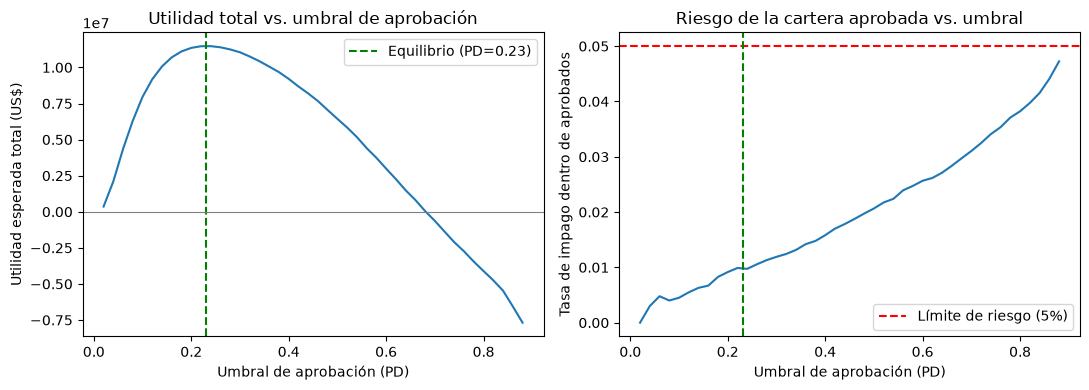

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(policy_curve['umbral_pd'], policy_curve['utilidad_total'])
axes[0].axvline(umbral_be, color='green', linestyle='--', label=f'Equilibrio (PD={umbral_be:.2f})')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_xlabel('Umbral de aprobación (PD)')
axes[0].set_ylabel('Utilidad esperada total (US$)')
axes[0].set_title('Utilidad total vs. umbral de aprobación')
axes[0].legend()

axes[1].plot(policy_curve['umbral_pd'], policy_curve['tasa_impago_aprobados'])
axes[1].axhline(MAX_DEFAULT_RATE, color='red', linestyle='--', label=f'Límite de riesgo ({MAX_DEFAULT_RATE:.0%})')
axes[1].axvline(umbral_be, color='green', linestyle='--')
axes[1].set_xlabel('Umbral de aprobación (PD)')
axes[1].set_ylabel('Tasa de impago dentro de aprobados')
axes[1].set_title('Riesgo de la cartera aprobada vs. umbral')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/p4_politica_aprobacion.png', dpi=150)
plt.show()

## 5. Análisis de sensibilidad

Se recalcula el umbral de equilibrio y la utilidad total del óptimo económico
bajo escenarios alternativos de tasa de interés y LGD, para no depender de un
único supuesto puntual.

In [6]:
scenarios = [
    ('Base', RATE, LGD),
    ('LGD alto (recupero menor)', RATE, 0.80),
    ('Tasa alta', 0.24, LGD),
    ('Tasa baja', 0.12, LGD),
]

sens_rows = []
for name, rate_s, lgd_s in scenarios:
    be_s = rate_s / (rate_s + lgd_s)
    util_s = (1 - pd_hat) * rate_s * LOAN_AMOUNT - pd_hat * lgd_s * LOAN_AMOUNT
    approved_s = pd_hat < be_s
    sens_rows.append({
        'escenario': name,
        'tasa': rate_s,
        'lgd': lgd_s,
        'umbral_be': round(be_s, 4),
        'tasa_aprobacion': round(approved_s.mean(), 3),
        'tasa_impago_aprobados': round(y_test[approved_s].mean(), 4),
        'utilidad_total': round(util_s[approved_s].sum(), 0),
    })

pd.DataFrame(sens_rows)

,escenario,tasa,lgd,umbral_be,tasa_aprobacion,tasa_impago_aprobados,utilidad_total
0,Base,0.18,0.6,0.2308,0.536,0.0097,11481802.0
1,LGD alto (recupero menor),0.18,0.8,0.1837,0.463,0.0084,9218552.0
2,Tasa alta,0.24,0.6,0.2857,0.598,0.0115,18274468.0
3,Tasa baja,0.12,0.6,0.1667,0.431,0.0072,5539972.0


## 6. Recomendación de decisión

**Aprobar a todo solicitante con PD estimada por el modelo de P3 menor a
23% (umbral de equilibrio económico), lo que implica aprobar ~53-55% de los
solicitantes evaluados.** Bajo los supuestos base (tasa 18%, LGD 60%, monto
uniforme US$ 10,000), esta política:

- Genera una utilidad esperada total positiva y maximal en el conjunto de
  evaluación (~US$ 11.5M sobre 22,500 solicitantes, es decir, escalable a
  ~US$ 511 por solicitante evaluado).
- Deja una tasa de default **dentro de los aprobados de ~1%**, muy por debajo
  del límite de riesgo evaluado (5%). **La restricción de riesgo no es
  vinculante bajo estos supuestos**: el óptimo puramente económico ya es más
  conservador que el límite de riesgo definido por el negocio. Esto es
  información valiosa en sí misma — indica que, con esta combinación de tasa
  y LGD, el equipo de riesgo tiene margen para relajar el apetito de riesgo
  si busca crecer la cartera, sin necesariamente perder rentabilidad marginal
  hasta acercarse al 23% de PD.
- Es sensible a la tasa de interés ofrecida: con una tasa más agresiva (24%)
  la utilidad total casi se duplica (~US$ 18.3M) porque el umbral de
  equilibrio sube a 28.6% y se aprueba más cartera manteniendo rentabilidad
  positiva; con una tasa más conservadora (12%) la utilidad cae a ~US$ 5.5M.
  La elección de tasa de interés es, en este modelo, una palanca más potente
  que el ajuste fino del umbral de score.

**Limitación explícita:** el monto de crédito uniforme (US$ 10,000) es la
simplificación más fuerte del ejercicio — en una implementación real, el
monto debería variar por capacidad de pago (ej. función de `MonthlyIncome` y
`DebtRatio`), lo que cambiaría el ranking de utilidad esperada entre clientes
y no solo su nivel. Se recomienda como siguiente iteración del modelo
prescriptivo antes de llevarlo a producción.

## 7. Exportar datasets (CSV para Power BI)

- `powerbi/clientes_test_scored.csv`: los 22,500 clientes de prueba con su
  PD estimada, segmento (de P2), variables clave y la marca de
  aprobado/rechazado bajo la política recomendada — para poder filtrar y
  cruzar libremente en Power BI (por segmento, tramo de edad, etc.).
- `powerbi/politica_curva.csv`: utilidad y riesgo por umbral de aprobación.
- `powerbi/politica_sensibilidad.csv`: los 4 escenarios de tasa/LGD.
- `powerbi/kpis.csv`: los indicadores de una sola cifra (para tarjetas).

In [7]:
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

umbral_recomendado = optimo_economico['umbral_pd']
age_bins = [0, 35, 50, 65, 120]
age_labels = ['<35', '35-49', '50-64', '65+']

clientes_test_scored = X_test.copy()
clientes_test_scored['tramo_edad'] = pd.cut(clientes_test_scored['age'], bins=age_bins, labels=age_labels)
clientes_test_scored['segmento'] = segmento_test
clientes_test_scored['impago_real'] = y_test
clientes_test_scored['pd_estimada'] = pd_hat
clientes_test_scored['aprobado'] = pd_hat < umbral_recomendado
clientes_test_scored.index.name = 'id_cliente'
clientes_test_scored.reset_index().to_csv(POWERBI_DIR / 'clientes_test_scored.csv', index=False)

policy_curve.to_csv(POWERBI_DIR / 'politica_curva.csv', index=False)
pd.DataFrame(sens_rows).to_csv(POWERBI_DIR / 'politica_sensibilidad.csv', index=False)

# Nota: el AUC/KS del modelo vive en powerbi/modelo_metricas.csv (P3);
# no se repite aquí para no duplicar la misma cifra en dos archivos.
kpis = pd.DataFrame([{
    'n_total_clientes': len(raw),
    'tasa_impago_global': round(raw[TARGET_COL].mean(), 4),
    'umbral_aprobacion_pd': round(umbral_recomendado, 4),
    'tasa_aprobacion_optima': round(optimo_economico['tasa_aprobacion'], 4),
    'tasa_impago_aprobados_optima': round(optimo_economico['tasa_impago_aprobados'], 4),
    'utilidad_total_optima': round(optimo_economico['utilidad_total'], 0),
    'n_test': len(pd_hat),
}])
kpis.to_csv(POWERBI_DIR / 'kpis.csv', index=False)

print('Guardados en', POWERBI_DIR, ':')
print('- clientes_test_scored.csv:', clientes_test_scored.shape)
print('- politica_curva.csv:', policy_curve.shape)
print('- politica_sensibilidad.csv')
print('- kpis.csv')

Guardados en C:\Users\user\Desktop\Analitica\powerbi :
- clientes_test_scored.csv: (22500, 17)
- politica_curva.csv: (44, 5)
- politica_sensibilidad.csv
- kpis.csv
